# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [1]:
# If on colab, uncomment the following lines

# ! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [3]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,71,97,59,108,227,70,11,224,30,25,186,225,732,218,70,10,25,186,198
1,129,100,48,95,209,68,7,199,32,23,150,216,605,200,73,7,11,192,194
2,206,92,46,79,176,64,8,162,41,20,149,183,396,178,67,2,10,191,198
3,810,97,55,103,197,63,11,215,31,24,172,219,677,219,75,5,24,185,194
4,394,90,49,83,187,63,7,176,37,21,154,205,467,222,70,1,2,189,195
5,507,93,35,78,162,60,8,150,45,19,125,172,331,137,67,2,33,191,198
6,415,101,53,108,184,54,12,216,31,24,172,220,685,187,68,4,24,190,201
7,610,103,56,105,183,59,10,210,32,24,173,217,648,218,72,13,22,188,196
8,514,89,38,74,138,59,7,136,49,18,133,167,278,128,72,7,7,189,193
9,625,104,53,101,190,63,10,213,32,24,166,218,664,202,74,13,21,188,198


Methods `describe` and `info` deliver some useful information.

In [4]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.00000,549.000000
mean,414.347905,93.965392,44.938069,82.644809,169.422587,61.533698,8.550091,170.114754,40.721311,20.684882,148.065574,189.236794,447.349727,174.854281,72.335155,6.495446,13.091075,188.96357,195.788707
std,245.485883,8.541263,6.314144,16.335317,33.309759,7.546284,4.604796,34.316362,8.092797,2.674728,14.787894,32.082672,182.146492,33.169448,7.283409,5.012983,9.158922,6.20620,7.502736
min,0.000000,73.000000,33.000000,42.000000,104.000000,47.000000,2.000000,114.000000,26.000000,17.000000,118.000000,131.000000,191.000000,112.000000,59.000000,0.000000,0.000000,176.00000,181.000000
25%,200.000000,88.000000,40.000000,70.000000,141.000000,57.000000,7.000000,146.000000,33.000000,19.000000,136.000000,167.000000,319.000000,148.000000,67.000000,3.000000,6.000000,184.00000,191.000000
50%,412.000000,93.000000,44.000000,81.000000,169.000000,61.000000,8.000000,158.000000,43.000000,20.000000,146.000000,179.000000,367.000000,173.000000,71.000000,6.000000,12.000000,189.00000,197.000000
75%,625.000000,100.000000,50.000000,98.000000,195.000000,65.000000,10.000000,201.000000,46.000000,23.000000,160.000000,218.000000,608.000000,200.000000,75.000000,10.000000,20.000000,193.00000,201.000000
max,844.000000,119.000000,59.000000,110.000000,322.000000,133.000000,55.000000,265.000000,59.000000,29.000000,186.000000,288.000000,1018.000000,264.000000,127.000000,22.000000,41.000000,206.00000,211.000000


In [5]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

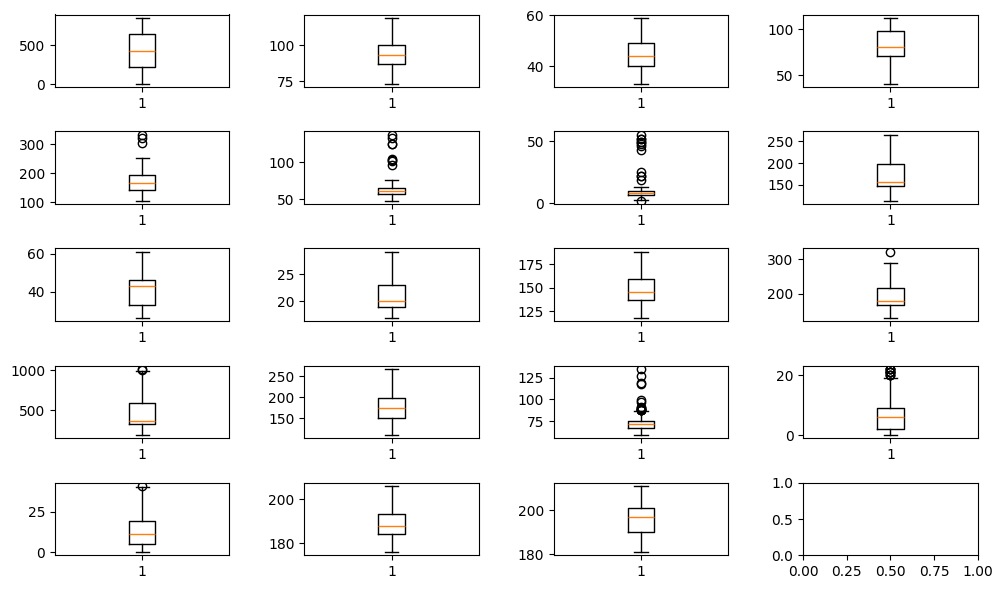

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5,4, figsize=(10, 6))
fig.tight_layout(w_pad=2)
axs = axs.ravel()
for i in range(19):
    axs[i].boxplot(data[:,i])

In [7]:
# Очевидно, признаки разных масштабов, необходимо масштабировать и нормализовать. Пропусков нет. Масштабирования и нормализация
# типичные требования для большинства моделей.

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)

In [10]:
X_test_std = scaler.transform(X_test)

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [11]:
import random

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, accuracy_score
from scikitplot.metrics import plot_roc

random.seed(10)

import warnings
warnings.filterwarnings('ignore')

In [12]:
# You might use this command to install scikit-plot. 
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding 
# virtual environment instead

# ! pip install scikit-plot

In [13]:
param_grid = [
    {
        'multi_class': ['multinomial'],
        'solver': ['saga'],
        'tol': [1e-3],
        'max_iter': [500],
        'penalty': ['l1', 'l2'],
        'C': [1.0, 1.5, 2],
        'fit_intercept': [True, False],
    },
    {
        'multi_class': ['multinomial'],
        'solver': ['saga'],
        'tol': [1e-3],
        'max_iter': [500],
        'penalty': ['elasticnet'],
        'C': [1.0, 1.5, 2],
        'fit_intercept': [True, False],
        'l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0]
    }
]

In [14]:
log_reg_gs = GridSearchCV(LogisticRegression(), param_grid, scoring='roc_auc', verbose=1, n_jobs=-1)
log_reg_gs.fit(X_train_std, y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


,estimator,LogisticRegression()
,param_grid,"[{'C': [1.0, 1.5, ...], 'fit_intercept': [True, False], 'max_iter': [500], 'multi_class': ['multinomial'], ...}, {'C': [1.0, 1.5, ...], 'fit_intercept': [True, False], 'l1_ratio': [0.0, 0.2, ...], 'max_iter': [500], ...}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [15]:
log_reg_gs.best_params_

{'C': 1.0,
 'fit_intercept': True,
 'max_iter': 500,
 'multi_class': 'multinomial',
 'penalty': 'l1',
 'solver': 'saga',
 'tol': 0.001}

In [16]:
y_pred = log_reg_gs.best_estimator_.predict(X_test_std)

In [17]:
pred_proba = log_reg_gs.best_estimator_.predict_proba(X_test_std)

In [18]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {acc:.3f}')
print(f'f1: {f1:.3f}')

Accuracy: 0.788
f1: 0.778


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

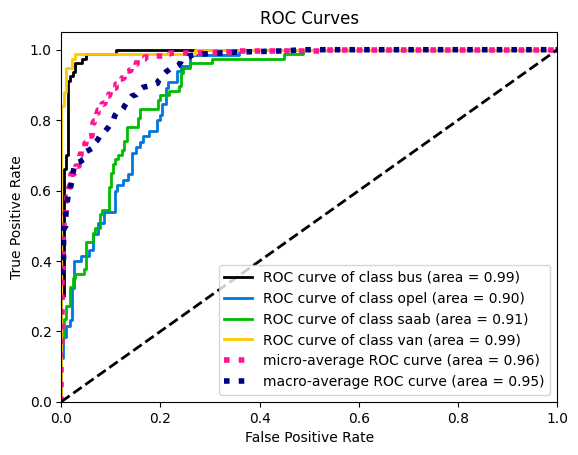

In [19]:
plot_roc(y_test, pred_proba)

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot. 

In [20]:
from sklearn.decomposition import PCA

In [21]:
comp, expl_var = [], []
for n_components in range(1, X_train.shape[1]):
    pca = PCA(n_components=n_components).fit(X_train_std)
    var_ = pca.explained_variance_ratio_.sum()
    comp.append(n_components)
    expl_var.append(var_)
    print(f"N components: {n_components}, explained var: {var_:.3f}")

N components: 1, explained var: 0.503
N components: 2, explained var: 0.663
N components: 3, explained var: 0.760
N components: 4, explained var: 0.822
N components: 5, explained var: 0.874
N components: 6, explained var: 0.922
N components: 7, explained var: 0.948
N components: 8, explained var: 0.966
N components: 9, explained var: 0.978
N components: 10, explained var: 0.986
N components: 11, explained var: 0.990
N components: 12, explained var: 0.993
N components: 13, explained var: 0.996
N components: 14, explained var: 0.997
N components: 15, explained var: 0.998
N components: 16, explained var: 0.999
N components: 17, explained var: 1.000
N components: 18, explained var: 1.000


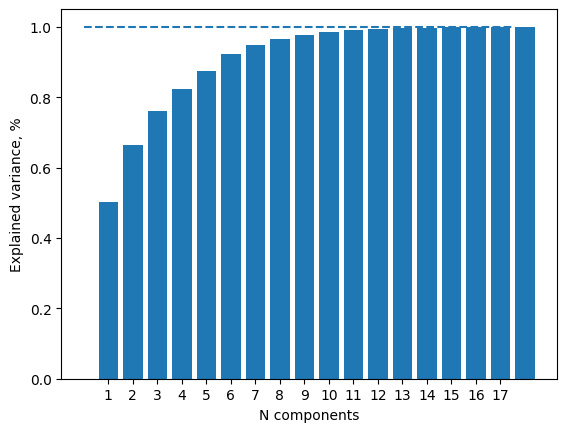

In [22]:
fig, ax = plt.subplots()

ax.bar(comp, expl_var)
ax.set_ylabel('Explained variance, %')
ax.set_xlabel('N components')
ax.set_xticks(range(1, 18), [str(i) for i in range(1, 18)])
ax.hlines(1,xmin=0, xmax=17.5, linestyles='--')

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

In [23]:
# Оставим 7 компонент, т.к. этого достаточно для объяснения 95% всей дисперсии.
# Да, данные нужно нормализовать, чтобы какой нибудь признак сильно не "перевешивал". Данные уже были нормализованы выше

In [24]:
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

In [25]:
param_grid = [
    {
        'multi_class': ['multinomial'],
        'solver': ['saga'],
        'tol': [1e-3],
        'max_iter': [500],
        'penalty': ['l1', 'l2'],
        'C': [1.0, 1.5, 2],
        'fit_intercept': [True, False],
    },
    {
        'multi_class': ['multinomial'],
        'solver': ['saga'],
        'tol': [1e-3],
        'max_iter': [500],
        'penalty': ['elasticnet'],
        'C': [1.0, 1.5, 2],
        'fit_intercept': [True, False],
        'l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0]
    }
]

In [26]:
gs_pca = GridSearchCV(LogisticRegression(), param_grid, scoring='roc_auc', verbose=1, n_jobs=-1)
gs_pca.fit(X_train_pca, y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


,estimator,LogisticRegression()
,param_grid,"[{'C': [1.0, 1.5, ...], 'fit_intercept': [True, False], 'max_iter': [500], 'multi_class': ['multinomial'], ...}, {'C': [1.0, 1.5, ...], 'fit_intercept': [True, False], 'l1_ratio': [0.0, 0.2, ...], 'max_iter': [500], ...}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [27]:
y_pred = gs_pca.best_estimator_.predict(X_test_pca)
pred_proba = gs_pca.best_estimator_.predict_proba(X_test_pca)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {acc:.3f}')
print(f'f1: {f1:.3f}')

Accuracy: 0.586
f1: 0.560


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

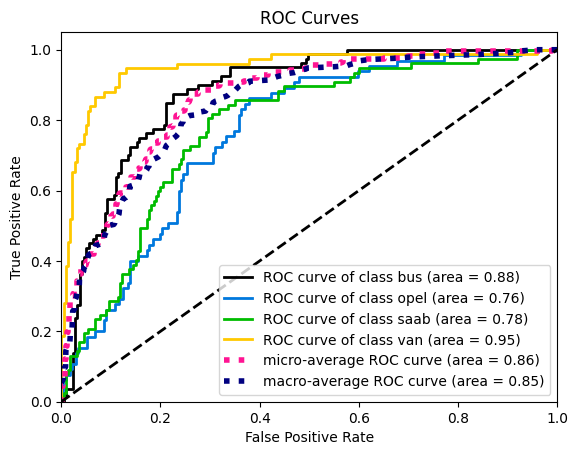

In [28]:
plot_roc(y_test, pred_proba)

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
tree_parameters = {
    'max_depth': np.arange(2, 9),
}

In [31]:
# для деревьев признаки можно не нормализовывать
gs_dt = GridSearchCV(DecisionTreeClassifier(), tree_parameters, scoring='roc_auc', verbose=1, n_jobs=-1)
gs_dt.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': array([2, 3, 4, 5, 6, 7, 8])}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [32]:
gs_dt.best_params_

{'max_depth': 2}

In [33]:
y_pred = gs_dt.best_estimator_.predict(X_test)
pred_proba = gs_dt.best_estimator_.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {acc:.3f}')
print(f'f1: {f1:.3f}')

Accuracy: 0.522
f1: 0.447


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

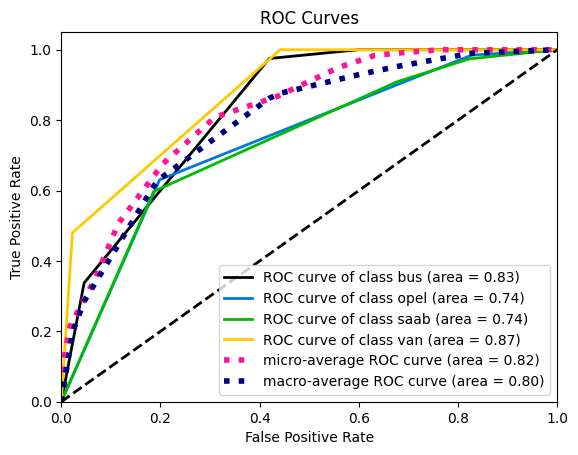

In [34]:
plot_roc(y_test, pred_proba)

#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble? 

In [35]:
from sklearn.utils import resample
from tqdm import tqdm

In [36]:
# Bootrstrap - выбираем n объектов равновероятно с возвращением. В sklearn есть функция resample для реализации бутстрапа

In [37]:
def voting_classifier(preds: list[np.ndarray]) -> list[str]:
    """
    Выбирает из всех предсказаний самый часто встречающийся класс
    """
    from collections import Counter
    
    final_pred = []
    n = len(preds[0])
    k = len(preds)
    for i in range(n):
        nth_pred = []
        for j in range(k):
            y_pred = preds[j][i]
            nth_pred.append(y_pred)
        counter = Counter(nth_pred)
        most_common = counter.most_common(1)[0]
        final_pred.append(most_common[0])
    return final_pred

In [38]:
def bagging(x_train, y_train, x_test, y_test, base_estimator, n_estimators, estimator_params):
    """
    Реализует ансамблевый классификатор bagging, построенный на базовых алгоритмах типа base_estimator
    """
    size = len(x_train)

    acc, f1 = [], []
    for n in tqdm(n_estimators):
        pred = []
        for i in range(n):
            x_bts, y_bts = resample(x_train, y_train, replace=True, n_samples=size)
            model = base_estimator(**estimator_params)
            model.fit(x_bts, y_bts)
            model_pred = model.predict(x_test)
            pred.append(model_pred)

        ensemble_pred = voting_classifier(pred)
        acc.append(accuracy_score(y_test, ensemble_pred))
        f1.append(f1_score(y_test, ensemble_pred, average='macro'))

    return acc, f1

In [39]:
n_estimators = np.arange(2,100,5)

In [40]:
dt_acc, dt_f1 = bagging(X_train, y_train, X_test, y_test, DecisionTreeClassifier, n_estimators, gs_dt.best_params_)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 11.43it/s]


In [41]:
log_reg_acc, log_reg_f1 = bagging(X_train_std, y_train, X_test_std, y_test, LogisticRegression, n_estimators, log_reg_gs.best_params_)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:40<00:00,  5.01s/it]


In [42]:
# найдем количество моделей, которое соответствует наилучшей метрике
ind = np.argmax(log_reg_acc)
best_log_estimators = n_estimators[ind]
log_max_score = log_reg_acc[ind]

In [43]:
best_log_estimators

7

In [44]:
ind = np.argmax(dt_acc)
best_dt_estimators = n_estimators[ind]
dt_max_score = dt_acc[ind]

In [45]:
best_dt_estimators

2

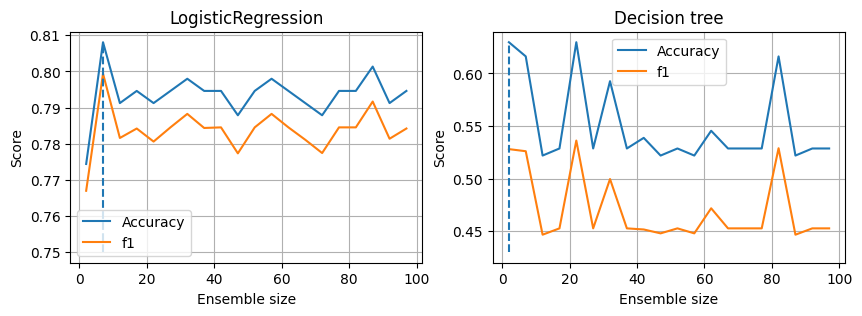

In [46]:
fig, axs = plt.subplots(1,2, figsize=(10, 3))

axs[0].plot(n_estimators, log_reg_acc, label='Accuracy')
axs[0].plot(n_estimators, log_reg_f1, label='f1')
axs[0].vlines(best_log_estimators, 0.75, log_max_score, linestyles='--')
axs[0].set_ylabel('Score')
axs[0].set_xlabel('Ensemble size')
axs[0].set_title('LogisticRegression')

axs[1].plot(n_estimators, dt_acc, label='Accuracy')
axs[1].plot(n_estimators, dt_f1, label='f1')
axs[1].vlines(best_dt_estimators, 0.43, dt_max_score, linestyles='--')
axs[1].set_ylabel('Score')
axs[1].set_xlabel('Ensemble size')
axs[1].set_title('Decision tree')


axs[0].legend()
axs[1].legend()
axs[0].grid(True)
axs[1].grid(True)

In [91]:
# Построим ансамбль с максимальной глубиной 6, результаты должны улучшиться. Сделаем этот эксперимент просто чтоб проверить, что более 
# глубокие деревья лучше работают в бэггинге

In [87]:
dt_acc_2, dt_f1_2 = bagging(X_train, y_train, X_test, y_test, DecisionTreeClassifier, n_estimators, {"max_depth": 6})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  6.07it/s]


In [88]:
ind = np.argmax(dt_acc_2)
best_dt_estimators = n_estimators[ind]
dt_max_score = dt_acc_2[ind]

In [89]:
best_dt_estimators

7

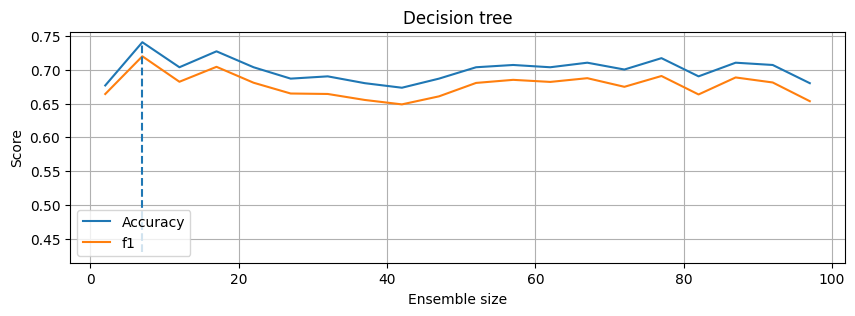

In [90]:
fig, axs = plt.subplots(1,1, figsize=(10, 3))

axs.plot(n_estimators, dt_acc_2, label='Accuracy')
axs.plot(n_estimators, dt_f1_2, label='f1')
axs.vlines(best_dt_estimators, 0.43, dt_max_score, linestyles='--')
axs.set_ylabel('Score')
axs.set_xlabel('Ensemble size')
axs.set_title('Decision tree')
axs.legend()
axs.grid(True)

Будем считать оптимальным наименьшее количество моделей в ансамбле, обеспечивающее при этом максимальную точность.
Для данного примера видим, что ансамбль на логистической регрессии достигает наибольшей точности на 7 классификаторах, в то время как ансамблю на деревьях требуется 2. Отметим, что результаты получаются очень разные в зависимости от случайного разбиения.

Были использованы те же параметры, которые мы нашли с помощью решетчатого поиска для одной модели, однако, они не являются оптимальными в случае ансамбля, в особенности это относится к ансамблю деревьев. Единичное дерево, как правило, имеет лучшую обобщающую способность при относительно небольшой глубине, в то время как для ансамбля лучше построить больше глубоких деревьев (чтоб было за счет чего снижать дисперсию).

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": np.arange(2,8),
    "min_samples_split": np.arange(2,10),
    "min_samples_leaf": np.arange(1,10),
    "max_features": ["sqrt", "log2"],
}

In [53]:
gs_rf = GridSearchCV(RandomForestClassifier(), rf_params, scoring='roc_auc', verbose=1, n_jobs=-1)
gs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': array([2, 3, 4, 5, 6, 7]), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([1, 2, ..., 6, 7, 8, 9]), ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [54]:
gs_rf.best_params_

{'criterion': 'gini',
 'max_depth': 2,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [55]:
acc = []
f1 = []
for n_est in n_estimators:
    rf = RandomForestClassifier(n_estimators=n_est, bootstrap=True, **gs_rf.best_params_)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, y_pred)
    rf_f1  = f1_score(y_test, y_pred, average='macro')
    acc.append(rf_acc)
    f1.append(rf_f1)

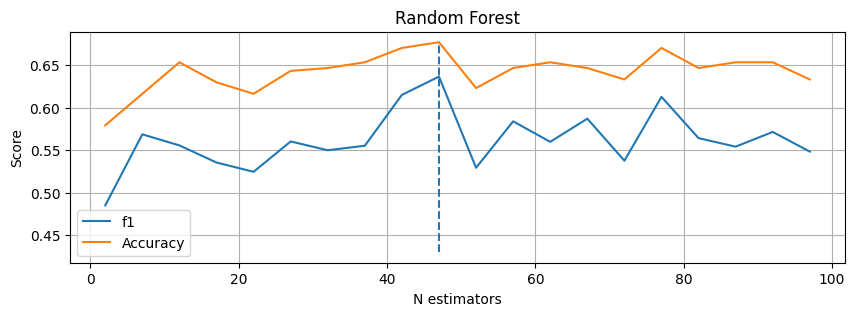

In [56]:
fig, axs = plt.subplots(1,1, figsize=(10, 3))

ind = np.argmax(acc)
best_dt_estimators = n_estimators[ind]
dt_max_score = acc[ind]

axs.plot(n_estimators, f1, label='f1')
axs.plot(n_estimators, acc, label='Accuracy')
axs.vlines(best_dt_estimators, 0.43, dt_max_score, linestyles='--')
axs.set_ylabel('Score')
axs.set_xlabel('N estimators')
axs.set_title('Random Forest')

axs.legend()
axs.grid(True)

In [57]:
# Количество моделей в ансамбле отличается. Отличие объясняется тем, что за bagging'ом и случайным лесом стоят несколько разные идеи.
# Когда мы строим ансамбль методом bagging'a мы используем предположение, что модели ансамбля будут некоррелированы, а вариативность
# обучения обеспечиваем за счет бутстрапа. Случайный лес пытается добиться некоррелированности моделей за счет случайных 
# подвыборок признаков + бутстрап.

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it? 

In [58]:
def train_model(x_train_bts, y_train_bts, x_test, y_test, base_estimator, estimator_params):
    model = base_estimator(**estimator_params)
    model.fit(x_train_bts, y_train_bts)
    acc = accuracy_score(y_test, model.predict(x_test))
    f1 = f1_score(y_test, model.predict(x_test), average='macro')
    return acc, f1

In [59]:
N = len(X_train)

params = [
        (X_train_std, y_train, X_test_std, y_test, LogisticRegression, log_reg_gs.best_params_),
        (X_train, y_train, X_test, y_test, DecisionTreeClassifier, gs_dt.best_params_),
        (X_train, y_train, X_test, y_test, RandomForestClassifier, gs_rf.best_params_),
]

res = []
for frac in np.arange(0.1, 1.1, 0.1):
    n = int(N * frac)
    part_results = []
    for param in params:
        x_train, y_train, x_test, y_test, model_type, model_params = param
        x_train_bts, y_train_bts = resample(x_train, y_train, replace=True, n_samples=n, stratify=y_train)
        acc, f1 = train_model(x_train_bts, y_train_bts, x_test, y_test, model_type, model_params)
        
        part_res = {}
        part_res["model_name"] = model_type.__name__
        part_res["acc"] = acc
        part_res["f1"] = f1
        part_res["train_size"] = n
        part_results.append(part_res)
    res.append(part_results)

In [60]:
records = []
for part_results in res:
    for r in part_results:
        records.append(r)

df = pd.DataFrame(records)
df.head()

,model_name,acc,f1,train_size
0,LogisticRegression,0.686869,0.670300,54
1,DecisionTreeClassifier,0.397306,0.316972,54
2,RandomForestClassifier,0.538721,0.492910,54
3,LogisticRegression,0.727273,0.715082,109
4,DecisionTreeClassifier,0.545455,0.471402,109


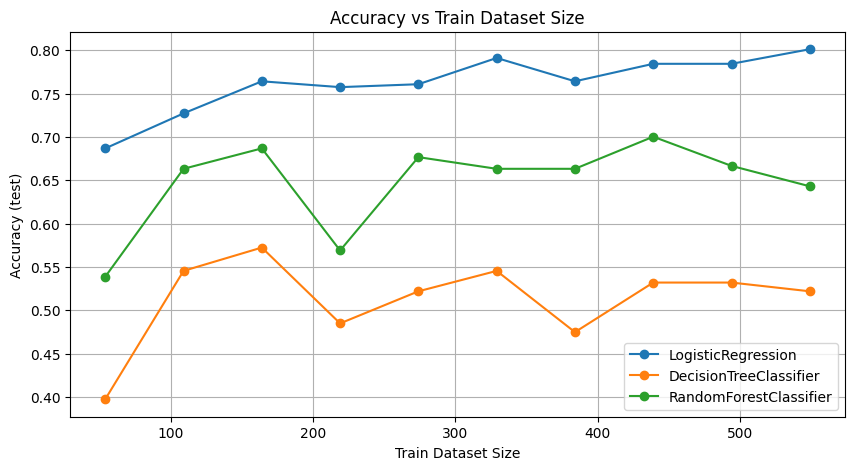

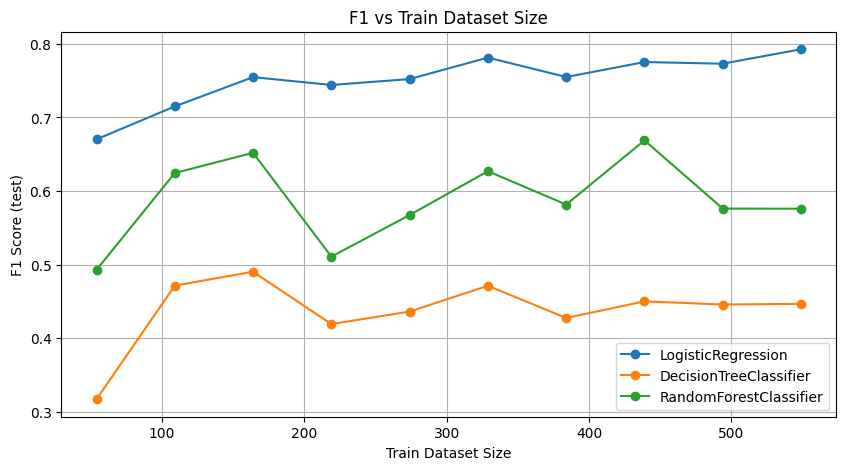

In [61]:
df = df.sort_values("train_size")

plt.figure(figsize=(10, 5))

for model_name in df["model_name"].unique():
    sub = df[df["model_name"] == model_name]
    plt.plot(sub["train_size"], sub["acc"], marker='o', label=model_name)

plt.xlabel("Train Dataset Size")
plt.ylabel("Accuracy (test)")
plt.title("Accuracy vs Train Dataset Size")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

for model_name in df["model_name"].unique():
    sub = df[df["model_name"] == model_name]
    plt.plot(sub["train_size"], sub["f1"], marker='o', label=model_name)

plt.xlabel("Train Dataset Size")
plt.ylabel("F1 Score (test)")
plt.title("F1 vs Train Dataset Size")
plt.grid(True)
plt.legend()
plt.show()

In [77]:
# Самым робастным методом для данной задачи оказалась логистическая регрессия. Точность регрессии растет примерно линейно с увеличением 
# объема выборки.

# Деревья на данном датасете работают значительно хуже. На графиках мы видим, что точность растёт и на случайном лесе и на единичном дереве,
# однако рост происходит нестабильно, после достижения объема ~0.3 выборки значительных улучшений не наблюдается.

#### 2.9. Boosting
Your goal is to build a boosting ensemble using xgboost, CatBoost or lightgbm package.
Please, do not use the sklearn API for these models.

Find optimal number of decision trees in the boosting ensembe using grid search or other methods.
Please, explain your answer.

In [63]:
# !pip install xgboost

In [64]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [65]:
num_class = len(set(y_train))

In [66]:
# xgbootst не понимает имена классов, нужны метки
le = LabelEncoder()

In [67]:
le = le.fit(list(set(y_train)))

In [68]:
le.classes_

array(['bus', 'opel', 'saab', 'van'], dtype='<U4')

In [69]:
y_train_idx = le.transform(y_train)

In [70]:
xgb_param_grid = {
    'n_estimators': np.arange(2,100,5),
    'learning_rate': [0.05, 0.1, 0.2, 0.5],
    'max_depth': [3, 5, 7, 9, 11],
    'objective': ['multi:softmax'],
    'eval_metric': ['auc', 'mlogloss']
}

In [71]:
gs_xgb = GridSearchCV(XGBClassifier(), xgb_param_grid, scoring='roc_auc', verbose=1, n_jobs=-1)
gs_xgb.fit(X_train_std, y_train_idx)

Fitting 5 folds for each of 800 candidates, totalling 4000 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'eval_metric': ['auc', 'mlogloss'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': array([ 2, 7... 87, 92, 97]), ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softmax'


In [72]:
gs_xgb.best_params_

{'eval_metric': 'auc',
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 2,
 'objective': 'multi:softmax'}

In [73]:
pred = gs_xgb.best_estimator_.predict(X_test_std)
pred_proba = gs_xgb.best_estimator_.predict_proba(X_test_std)

In [74]:
pred_classes = le.inverse_transform(pred)

In [75]:
acc = accuracy_score(y_test, pred_classes)
f1  = f1_score(y_test, pred_classes, average='macro')

print(f'Accuracy: {acc:.3f}')
print(f'f1: {f1:.3f}')

Accuracy: 0.680
f1: 0.646


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

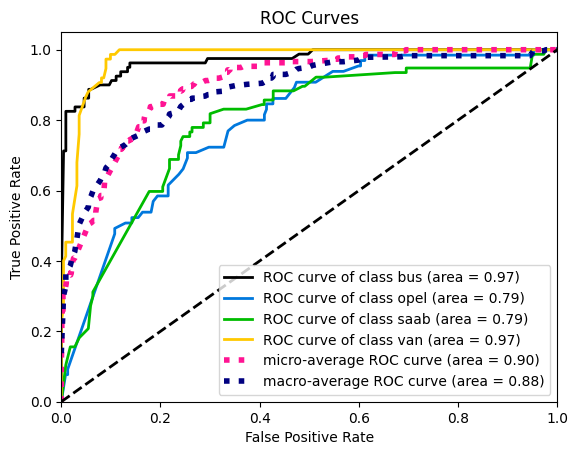

In [76]:
plot_roc(y_test, pred_proba)

In [78]:
# Получили примерно тот же результат, что и при обучении методом bagging: оптимальное количество моделей 2, глубина 3, что на 1 больше
# чем у случайного леса, обученного выше. 